In [1]:
import os
import re
import time
import json
import random
import numpy as np
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

from WJYML.model_trainer import *
from WJYML.data_loader import MyDataset,ImportVar
from WJYML.models.builder import ModelBuilder

import matplotlib.pyplot as plt

import warnings
# 忽略所有的FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

today = time.strftime('%Y-%m-%d')
print(today)

file_path = os.getcwd() # 当前文件所在目录，或者直接改MODEL PATH
MODEL_PATH = f'{file_path}/model_train/'
DS_PATH = f'{MODEL_PATH}data_store/'
MS_PATH = f'{MODEL_PATH}model_save/'

# 统计
def iter_isos_summary(col_name,df_pred_tmp):
    # df_pred_tmp = df_pred.pivot_table(index='datetime',columns='instrument',values=col_name)
    df_pred_tmp = df_pred_tmp.to_frame().reset_index()\
                .pivot_table(index='datetime',columns='instrument',values=col_name)
    split_date = train_e
    # df_ic = df_true.corrwith(df_pred_tmp,axis=1).to_frame('ic')
    df_ic = df_true.rank(axis=1).corrwith(df_pred_tmp.rank(axis=1),axis=1).to_frame('ic')
    
    df_ic.cumsum(axis=0).plot(figsize=(20,8),grid=True)
    # plt.axvline(x=split_date, color='r', linestyle='--')

    df_is_ic = df_ic.loc[train_date,'ic']
    df_os_ic = df_ic.loc[mask_date[5:-5],'ic']

    is_icmean = df_is_ic.mean()
    # is_icir = abs(df_is_ic.mean()) / df_is_ic.std()

    os_icmean = df_os_ic.mean()
    # os_icir = abs(df_os_ic.mean()) / df_os_ic.std()
    return [col_name, is_icmean, os_icmean]

#作图
def osis_plot(df_epoch_tmp):
    df_epoch_tmp['epoch'] = df_epoch_tmp['epoch'].apply(lambda x: int(x.replace('epoch','')))
    df_epoch_tmp = df_epoch_tmp.set_index('epoch')
    df_epoch_tmp.plot(figsize=(10,5),grid=True)
    plt.savefig(MS_ONE + 'epoch_result.png')
    plt.show()

def makedir(path_new):
    if not os.path.exists(path_new):
        os.makedirs(path_new)


2025-03-24


In [ ]:
# 读取run_map获得模型训练的设置 
with open(f"{MS_PATH}2025-03-24/for2025_5fold_label20_long_zzfull_158_icloss_rzscore_n_sigmoid_diff/run_map.json", 'r') as f:
    # json.dump(run_config, f)
    run_config = json.load(f)
for key, value in run_config.items():
    globals()[key] = value

print(run_config)
train_s, train_e = train_date_range.split('|')
pred_s, pred_e = pred_date_range.split('|')
pred_s = train_e 

model_dict = ModelBuilder(model_use,
                        seed_list,
                        model_config).model_dict_generate()

pred_ds = MyDataset(DS_PATH, dataset_name, pred_s, pred_e, 
                    feature_use_list = feature_use_list, label_use_list = label_use_list,
                    X_shape = X_shape, data_process_dict = data_process_dict)

nn_run = WJYNN(model_dict)
nn_run.load_models(MS_ONE)

{'today': '2025-03-24', 'dataset_name': 'example_alpha158_rzscore_n', 'model_save_name': 'for2025_5fold_label20_long_zzfull_158_icloss_rzscore_n_sigmoid_diff', 'train_date_range': '20240101|20250101', 'pred_date_range': '20240101|20260101', 'kfold_info': [5, 5], 'feature_use_list': [], 'label_use_list': ['LABEL20'], 'X_shape': [-1], 'data_process_dict': {'features': ['clip_10'], 'label': ['cs_rank', 'clip_5']}, 'model_use': 'mlp', 'loss_use': 'ic', 'seed_list': [1, 2, 3, 4, 5], 'total_epoch': 30, 'batch_size': 3000, 'learning_rate': 5e-06, 'batch_bydate': True, 'model_config': {'input_size': 158, 'units': [128, 64], 'dropout': 0.3, 'need_sigmoid': True, 'is_bn_first': True}, 'DS_PATH': 'd:\\jupyter_notebook\\WJYML_example/model_train/data_store/', 'MS_PATH': 'd:\\jupyter_notebook\\WJYML_example/model_train/model_save/', 'MS_ONE': 'd:\\jupyter_notebook\\WJYML_example/model_train/model_save/2025-03-24/for2025_5fold_label20_long_zzfull_158_icloss_rzscore_n_sigmoid_diff/'}
----------------

2025-03-24 17:14:48,122 - MyLogger - INFO     features clip_10 processing...
2025-03-24 17:14:49,169 - MyLogger - INFO     features clip done
2025-03-24 17:14:49,403 - MyLogger - INFO     label cs_rank processing...
2025-03-24 17:14:49,654 - MyLogger - INFO     label cs_rank done
2025-03-24 17:14:49,808 - MyLogger - INFO     label clip_5 processing...
2025-03-24 17:14:50,126 - MyLogger - INFO     label clip done
2025-03-24 17:14:50,267 - MyLogger - INFO     process done!


In [3]:
# 输出预测值
pred_dict = nn_run.pred(pred_ds,num_workers=0,saving_all_epoch_res=True)

pred_dict = {key: pred_dict[key] for key in [f'epoch{i+1}' for i in range(total_epoch)] if key in pred_dict}
with open(MS_ONE + 'train_output.json', 'r') as f:
    train_info = json.load(f)
    
train_output = np.load(MS_ONE + 'train_output.npy')
train_label = np.load(MS_ONE + 'train_label.npy')
print(train_output.shape, train_label.shape)

train_dict = dict(zip(train_info['train_epoch_list'],train_output))
combine_dict = {}
for k in pred_dict:
    combine_dict[k] = np.concatenate([train_dict[k], np.array(pred_dict[k])],axis=1)
combine_label = np.concatenate([train_label,pred_ds.label],axis=0)

combine_idx_sep_list = train_info['idx_sep_list'] + pred_ds.idx_sep_list.tolist()
combine_idx_dict = dict((list(enumerate(['|'.join(i) for i in combine_idx_sep_list]))))

100%|██████████| 127/127 [00:12<00:00,  9.86it/s]


(30, 5, 1233403) (1233403, 1)


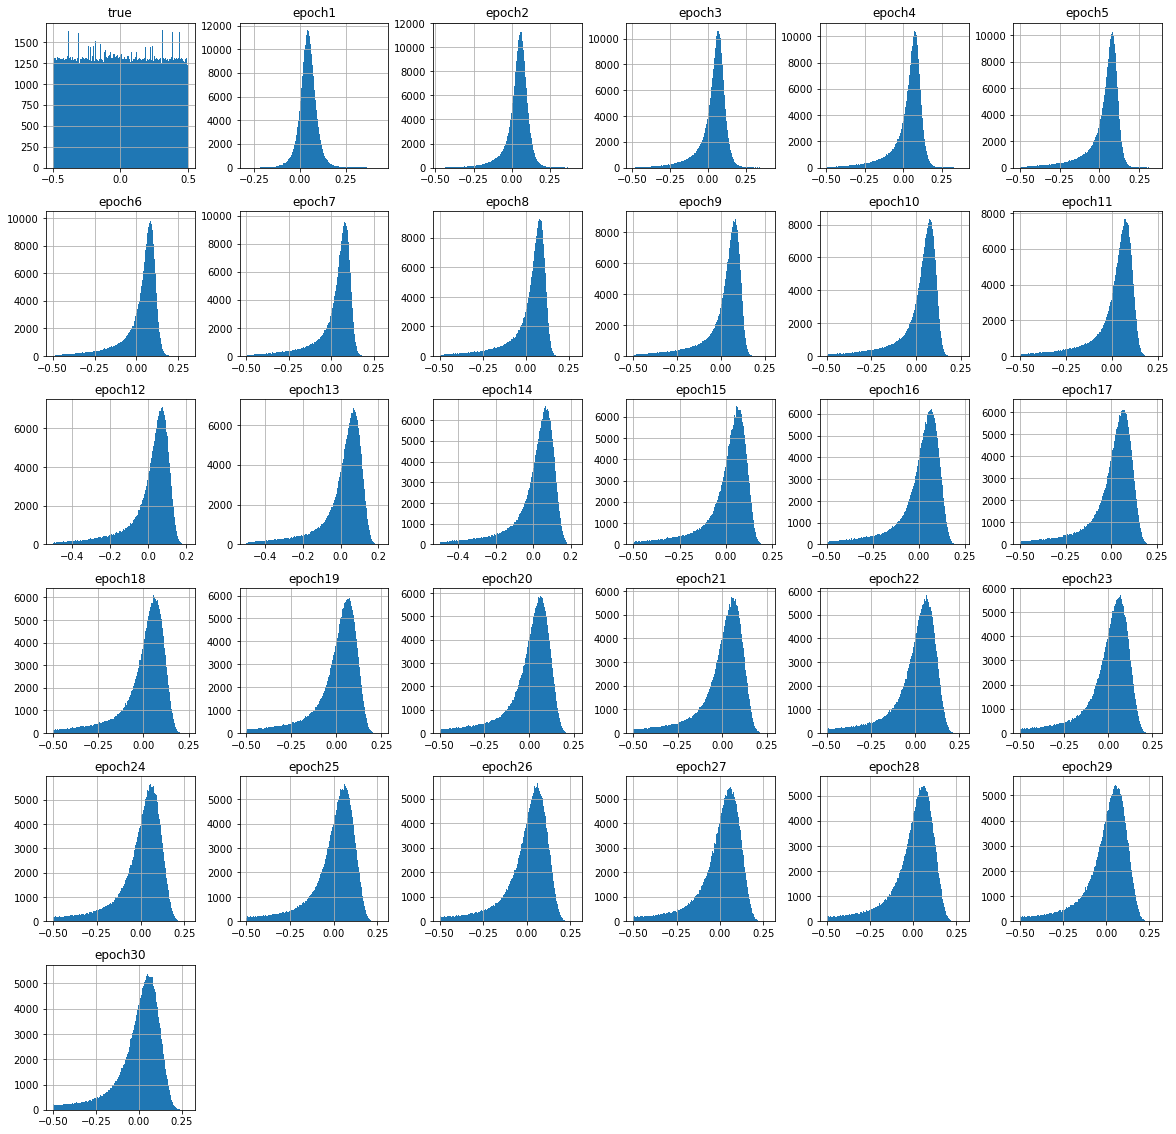

true    epoch1    epoch2    epoch3    epoch4  \
datetime   instrument                                                     
2024-01-02 000001      0.459717 -0.051166 -0.045663 -0.049753 -0.058975   
           000002      0.388916 -0.044409 -0.037947 -0.044245 -0.057794   
           000004     -0.054962  0.187000  0.143140  0.099170  0.056226   
           000005           NaN  0.204835  0.191130  0.168188  0.139223   
           000006      0.378418  0.003976  0.009842  0.012512  0.013372   
...                         ...       ...       ...       ...       ...   
2025-03-21 688799           NaN  0.104890  0.117652  0.118968  0.113838   
           688800           NaN  0.101427  0.109892  0.109220  0.103929   
           688819           NaN  0.043857  0.053970  0.060587  0.064782   
           688981           NaN -0.011848 -0.011433 -0.008739 -0.005160   
           689009           NaN  0.035370  0.034628  0.035992  0.038405   

                         epoch5    epoch6    epoch7    epoch8    epoch9  ...  \
datetime   instrument                                                    ...   
2024-01-02 000001     -0.071227 -0.085114 -0.099495 -0.113535 -0.126428  ...   
           000002     -0.075604 -0.094530 -0.113083 -0.131183 -0.148474  ...   
           000004      0.011963 -0.031946 -0.074661 -0.114752 -0.151111  ...   
           000005      0.106982  0.073730  0.041040  0.008789 -0.022009  ...   
           000006      0.013234  0.012518  0.011563  0.010573  0.009658  ...   
...                         ...       ...       ...       ...       ...  ...   
2025-03-21 688799      0.104903  0.093689  0.080923  0.067798  0.054818  ...   
           688800      0.095395  0.085021  0.073441  0.061332  0.049380  ...   
           688819      0.067510  0.069171  0.069979  0.070319  0.070290  ...   
           688981     -0.001425  0.002509  0.006418  0.010220  0.013750  ...   
           689009      0.041502  0.044902  0.048463  0.052050  0.055671  ...   

                        epoch21   epoch22   epoch23   epoch24   epoch25  \
datetime   instrument                                                     
2024-01-02 000001     -0.186475 -0.187610 -0.188489 -0.189001 -0.189343   
           000002     -0.231104 -0.232056 -0.232666 -0.232983 -0.232886   
           000004     -0.364893 -0.372119 -0.378564 -0.384180 -0.389111   
           000005     -0.234233 -0.243295 -0.251440 -0.258569 -0.265063   
           000006      0.010757  0.011294  0.011857  0.012508  0.013194   
...                         ...       ...       ...       ...       ...   
2025-03-21 688799     -0.022934 -0.025568 -0.028071 -0.030464 -0.032672   
           688800     -0.054448 -0.060273 -0.065718 -0.070884 -0.075828   
           688819      0.062087  0.061285  0.060498  0.059705  0.058919   
           688981      0.034944  0.035662  0.036332  0.036939  0.037505   
           689009      0.094895  0.097441  0.099885  0.102252  0.104521   

                        epoch26   epoch27   epoch28   epoch29   epoch30  
datetime   instrument                                                    
2024-01-02 000001     -0.189429 -0.189258 -0.189050 -0.188892 -0.188672  
           000002     -0.232446 -0.231812 -0.231079 -0.230029 -0.228857  
           000004     -0.393457 -0.397217 -0.400537 -0.403418 -0.406006  
           000005     -0.270642 -0.275696 -0.280273 -0.284302 -0.287939  
           000006      0.013902  0.014612  0.015299  0.016025  0.016759  
...                         ...       ...       ...       ...       ...  
2025-03-21 688799     -0.034682 -0.036405 -0.037946 -0.039266 -0.040491  
           688800     -0.080469 -0.084765 -0.088740 -0.092526 -0.096090  
           688819      0.058166  0.057426  0.056689  0.055940  0.055169  
           688981      0.038083  0.038617  0.039147  0.039640  0.040092  
           689009      0.106671  0.108693  0.110642  0.112509  0.114313  

[1493366 rows x 31 columns]

In [4]:
# 转化为df: 拼接版
toseed = False
if toseed: 
    # 转化为df: 拼接版 细化到输出每个epoch的每个seed
    output_list = [pd.DataFrame(combine_label,columns=['true'])]
    for k in combine_dict.keys():
        df_pred_tmp = pd.DataFrame(combine_dict[k],index = [f'{k}_seed{i}' for i in run_config['seed_list']]).T
        output_list.append(df_pred_tmp)
    df_pred = pd.concat(output_list,axis=1)
else:
    # 转化为df: 拼接版 只能细化到epoch输出，每个epoch对每个seed取mean
    pred_all = [combine_label.reshape(-1,)]
    for k in combine_dict.keys():
        pred_all.append(np.array(combine_dict[k]).mean(axis=0).reshape(-1,))
    df_pred = pd.DataFrame(np.array(pred_all)).T
    df_pred.columns = ['true'] + list(combine_dict.keys())
    df_pred.rename(index=combine_idx_dict,inplace=True)

df_pred[['datetime','instrument']] = combine_idx_sep_list
df_pred['datetime'] = pd.to_datetime(df_pred['datetime'])
df_pred = df_pred.set_index(['datetime','instrument'])

df_pred['true'] = df_pred['true'].astype(np.float64)
df_true = df_pred.pivot_table(index='datetime',columns='instrument',values='true')

epoch_list = sorted([c for c in df_pred.columns if 'epoch' in c],\
                    key=lambda x:int(''.join(re.findall(r'\d+', x.split('_')[0]))))
df_pred = df_pred[['true'] + epoch_list]

df_pred.hist(bins=1000,figsize=(20,20))
plt.show()

df_pred

[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  22 out of  30 | elapsed:   10.7s remaining:    3.8s
[Parallel(n_jobs=20)]: Done  30 out of  30 | elapsed:   11.3s finished


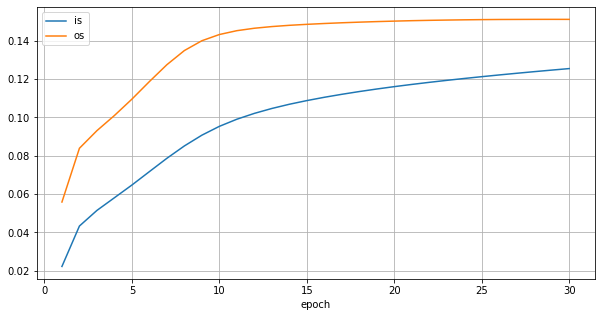

,28,29,27,26,25,24,23,22,21,20,...,9,8,7,6,5,4,3,2,1,0
epoch,29.000,30.000,28.000,27.000,26.000,25.000,24.000,23.000,22.000,21.000,...,10.000,9.000,8.000,7.000,6.000,5.000,4.000,3.000,2.000,1.000
is,0.125,0.125,0.124,0.123,0.122,0.121,0.120,0.119,0.118,0.117,...,0.095,0.091,0.085,0.079,0.072,0.065,0.058,0.051,0.043,0.022
os,0.151,0.151,0.151,0.151,0.151,0.151,0.151,0.151,0.151,0.150,...,0.143,0.140,0.135,0.127,0.119,0.109,0.101,0.093,0.084,0.056


In [5]:
# 划分样本内日期 做IC CV检验
total_group, mask_num = kfold_info
date_list = np.unique(np.sort(np.array(train_info['idx_sep_list'])[:,0]))
mask_date = np.array_split(date_list,total_group)[mask_num-1]

df_idx = pd.DataFrame(train_info['idx_sep_list'])
train_date = np.unique(np.sort(df_idx.loc[~df_idx[0].isin(mask_date)][0]))
 
toseed = any(['seed' in c for c in df_pred.columns])
epoch_res = Parallel(n_jobs=20,verbose=1)(delayed(iter_isos_summary)(c,\
               df_pred[c]) for c in epoch_list)

df_epoch_res = pd.DataFrame(epoch_res,columns=['epoch','is','os'])

if toseed:
    df_epoch_res[['epoch','seed']] = [i.split('_') for i in df_epoch_res['epoch']]
    for seed in df_epoch_res['seed'].unique():
        print(seed)
        df_epoch_tmp = df_epoch_res[df_epoch_res['seed']==seed].copy()
        osis_plot(df_epoch_tmp)
else:
    osis_plot(df_epoch_res)

df_epoch_res.sort_values(by='os',ascending=False).T.round(3)